<a href="https://colab.research.google.com/github/zeyekey/Introduction-To-Generative-AI/blob/main/HW1.1_Derin_%C3%96%C4%9Frenme_ile_Sald%C4%B1r%C4%B1_Tespiti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('/content/KDDTrain+.txt', header=None)
test_df = pd.read_csv('/content/KDDTest+.txt', header=None)

# Verinin ilk 5 satırı
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


# **Sütun İsimlerini Ekleme ve Gereksizleri Atma**

In [ ]:
# NSL-KDD sütun isimleri (Standart dizilim)
columns = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
           'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
           'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
           'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
           'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
           'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
           'attack', 'level']

# İsimleri tablolara atıyoruz
train_df.columns = columns
test_df.columns = columns

# 'level' sütununu siliyoruz (axis=1 sütun demek)
train_df.drop('level', axis=1, inplace=True)
test_df.drop('level', axis=1, inplace=True)

# **Sütun İsimlerini Eklemek ve Gereksizleri Atmak**

In [ ]:
# Eğer değer 'normal' ise 0, değilse 1 yap.
train_df['attack'] = train_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack'] = test_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

# **Metinleri Sayılara Çevirme (One-Hot Encoding)**

In [ ]:
# Kategorik sütunları belirliyoruz
categorical_cols = ['protocol_type', 'service', 'flag']

# Hangi satırın train, hangisinin test olduğunu unutmamak için geçici bir işaret koyuyoruz
train_df['is_train'] = 1
test_df['is_train'] = 0

# Tabloları alt alta birleştir
combined_df = pd.concat([train_df, test_df])

# One-Hot Encoding işlemini yap (Metinler sayılara dönüşüyor)
combined_df = pd.get_dummies(combined_df, columns=categorical_cols, dtype=float)

# Tabloları tekrar eski haline, iki ayrı tabloya ayır ve geçici işareti sil
train_df = combined_df[combined_df['is_train'] == 1].drop('is_train', axis=1)
test_df = combined_df[combined_df['is_train'] == 0].drop('is_train', axis=1)

# **X (Özellikler) ve Y (Hedef) Ayırımı + Ölçeklendirme (MinMaxScaler)**

In [ ]:
# X (Girdiler) ve y (Çıktılar/Etiketler) olarak ayır
X_train = train_df.drop('attack', axis=1)
y_train = train_df['attack']

X_test = test_df.drop('attack', axis=1)
y_test = test_df['attack']

# Tüm özellikleri 0 ile 1 arasına ölçeklendir
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Scaler'ı sadece eğitim verisine fit ediyoruz (öğretiyoruz), sonra her ikisine uyguluyoruz
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("İşlem Tamam! Eğitim verisi son boyutu:", X_train_scaled.shape)

İşlem Tamam! Eğitim verisi son boyutu: (125973, 122)


# **Veriyi CNN'in Anlayacağı Şekle Sokmak (Yeniden Boyutlandırma)**

In [ ]:
# Keras kütüphanelerini içe aktarıyoruz
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Veriyi 3 Boyutlu hale getiriyoruz (Reshape)
# 122 özelliğin yanına '1' kanalı ekliyoruz
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("CNN için yeni veri boyutu:", X_train_cnn.shape)

CNN için yeni veri boyutu: (125973, 122, 1)


# **CNN Mimarisini İnşa Etme**

In [ ]:
# Modeli sırayla inşa etmeye başlıyoruz
cnn_model = Sequential()

# 1. Evrişim (Convolution) Katmanı
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
cnn_model.add(MaxPooling1D(pool_size=2))

# 2. Evrişim Katmanı (Daha derin özellikler için)
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Veriyi düzleştiriyoruz
cnn_model.add(Flatten())

# Karar (Sınıflandırma) Katmanları
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dropout(0.5)) # Modelin veriyi ezberlemesini (overfitting) engellemek için nöronların %50'sini rastgele kapatır

# Çıktı Katmanı: Normal(0) mi Saldırı(1) mı?
# Sadece 2 ihtimal olduğu için tek nöron ve 'sigmoid' aktivasyonu kullanıyoruz.
cnn_model.add(Dense(1, activation='sigmoid'))

# Modeli Derleme (Compile): Hedefimiz kaybı (loss) düşürmek ve doğruluğu (accuracy) artırmak
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Modelin özetini görelim
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 120, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 58, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       118,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)

# **Eğitimi Başlatma**

In [ ]:
print("CNN Modeli Eğitimi Başlıyor... Lütfen bekleyin.")

# Eğitimi başlatıyoruz ve sonuçları cnn_history değişkenine kaydediyoruz (Grafikler için lazım olacak)
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

CNN Modeli Eğitimi Başlıyor... Lütfen bekleyin.
Epoch 1/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9623 - loss: 0.1235 - val_accuracy: 0.9777 - val_loss: 0.0535
Epoch 2/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.9798 - loss: 0.0551 - val_accuracy: 0.9827 - val_loss: 0.0445
Epoch 3/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.9814 - loss: 0.0468 - val_accuracy: 0.9838 - val_loss: 0.0394
Epoch 4/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.9811 - loss: 0.0422 - val_accuracy: 0.9838 - val_loss: 0.0371
Epoch 5/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.9850 - loss: 0.0391 - val_accuracy: 0.9876 - val_loss: 0.0307
Epoch 6/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.9873 - loss: 0.0349 - val_accuracy: 0.9888 - val_loss: 0.0282
Epoch 7/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - accuracy: 0.9889 - loss: 0.0316 - val_accuracy: 0.9906 - val_loss: 0.0253
Epoch 8/10
1575/1575 ━━━━━━━

# **Eğitim Süreci Grafikleri (Loss ve Accuracy)**

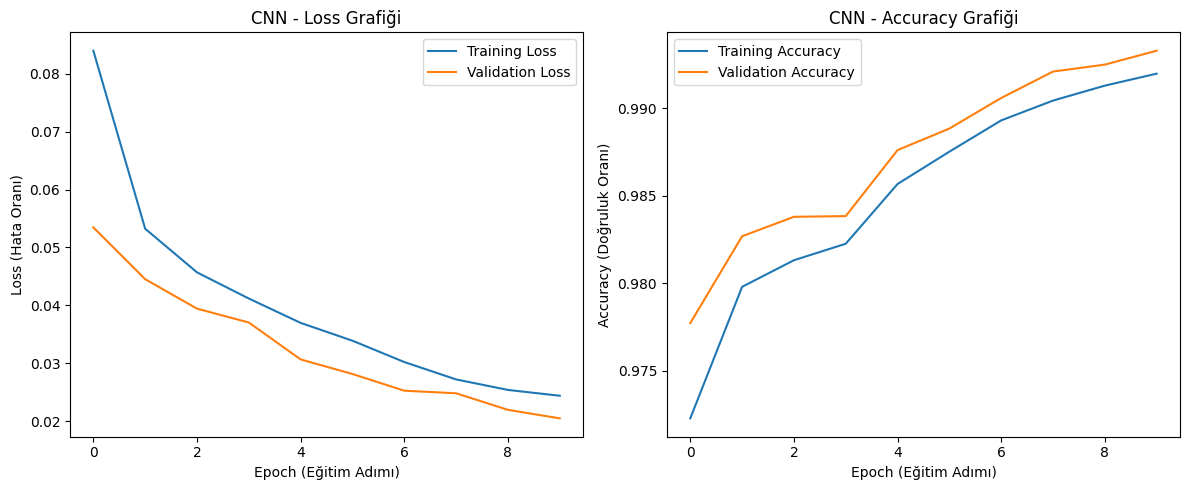

In [ ]:
# 1. Eğitim Grafikleri (Loss ve Accuracy)
plt.figure(figsize=(12, 5))

# Loss (Kayıp) Grafiği
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN - Loss Grafiği')
plt.xlabel('Epoch (Eğitim Adımı)')
plt.ylabel('Loss (Hata Oranı)')
plt.legend()

# Accuracy (Doğruluk) Grafiği
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN - Accuracy Grafiği')
plt.xlabel('Epoch (Eğitim Adımı)')
plt.ylabel('Accuracy (Doğruluk Oranı)')
plt.legend()

plt.tight_layout()
plt.show()

# **Modelin Test Edilmesi ve Metriklerin Hesaplanması**

705/705 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step
--- CNN MODELİ TEST SONUÇLARI ---
Accuracy (Doğruluk): 0.7588
Precision (Hassasiyet): 0.9307
Recall (Duyarlılık): 0.6226
F1-Score: 0.7461



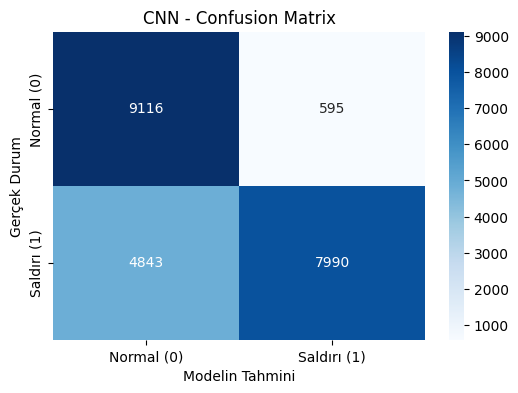

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Test verisi ile tahmin yapma
# Modelimiz 0 ile 1 arasında bir olasılık döndürür (örn: 0.85).
# 0.5'ten büyük olanları 1 (Saldırı), küçük olanları 0 (Normal) olarak yuvarlıyoruz.
y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred = (y_pred_probs > 0.5).astype(int)

# İstenen Metrikleri Hesaplama
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"--- CNN MODELİ TEST SONUÇLARI ---")
print(f"Accuracy (Doğruluk): {acc:.4f}")
print(f"Precision (Hassasiyet): {prec:.4f}")
print(f"Recall (Duyarlılık): {rec:.4f}")
print(f"F1-Score: {f1:.4f}\n")

# Karmaşıklık Matrisi (Confusion Matrix) Çizdirme
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Saldırı (1)'],
            yticklabels=['Normal (0)', 'Saldırı (1)'])
plt.ylabel('Gerçek Durum')
plt.xlabel('Modelin Tahmini')
plt.title('CNN - Confusion Matrix')
plt.show()

# **Autoencoder Modelini Kurma ve Eğitme**

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, UpSampling1D

# GİRİŞ KATMANI
input_layer = Input(shape=(X_train_cnn.shape[1], 1))

# ENCODER (Kodlayıcı) KISMI: Veriyi sıkıştırıp özünü (latent space) çıkarıyoruz
x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
encoded = MaxPooling1D(pool_size=2)(x) # 122 özellik 61'e düşüyor

# DECODER (Çözücü) KISMI: Sıkıştırılmış veriyi tekrar orijinal boyutuna getiriyoruz
x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(encoded)
x = UpSampling1D(size=2)(x) # 61 özellik tekrar 122'ye çıkıyor
decoded = Conv1D(filters=1, kernel_size=3, activation='sigmoid', padding='same')(x)

# Autoencoder Modeli (Girdi -> Çıktı)
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse') # Amaç: Orijinal veriyi en düşük hatayla (MSE) kopyalamak

print("Autoencoder Eğitimi Başlıyor (Etiket kullanılmıyor)...")
# Girdi de X_train_cnn, hedef de X_train_cnn!
ae_history = autoencoder.fit(
    X_train_cnn,
    X_train_cnn,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Autoencoder Eğitimi Başlıyor (Etiket kullanılmıyor)...
Epoch 1/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 0.0335 - val_loss: 7.1565e-04
Epoch 2/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 5.9952e-04 - val_loss: 3.0039e-04
Epoch 3/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - loss: 2.5340e-04 - val_loss: 1.8000e-04
Epoch 4/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - loss: 1.6884e-04 - val_loss: 1.4289e-04
Epoch 5/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - loss: 1.3240e-04 - val_loss: 1.1608e-04
Epoch 6/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - loss: 1.0858e-04 - val_loss: 9.5435e-05
Epoch 7/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 9.2580e-05 - val_loss: 8.0778e-05
Epoch 8/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - loss: 7.9086e-05 - val_loss: 7.4591e-05
Epoch 9/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - loss: 6.8811e-05 - val_loss: 6.1158e-05
Epoch 10/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 5.

# **AE-CNN Birleşik Mimarisini Kurma ve Eğitme**

In [ ]:
# Sadece eğittiğimiz Encoder kısmını alan yeni bir alt model tanımlıyoruz
encoder_model = Model(inputs=input_layer, outputs=encoded)

# AE-CNN Birleşik Modelini Başlatıyoruz
ae_cnn_model = Sequential()

# 1. Aşama: Özellik çıkarıcı olarak eğittiğimiz Encoder'ı başa ekliyoruz
ae_cnn_model.add(encoder_model)

# 2. Aşama: CNN Sınıflandırıcı Katmanları (İlk modele benziyor)
ae_cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
ae_cnn_model.add(MaxPooling1D(pool_size=2))
ae_cnn_model.add(Flatten())
ae_cnn_model.add(Dense(64, activation='relu'))
ae_cnn_model.add(Dropout(0.5))
ae_cnn_model.add(Dense(1, activation='sigmoid')) # Son karar katmanı (0 veya 1)

# Modeli Derleme
ae_cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nAE-CNN Sınıflandırıcı Eğitimi Başlıyor...")
ae_cnn_history = ae_cnn_model.fit(
    X_train_cnn,
    y_train, # Artık etiketleri (saldırı/normal) veriyoruz
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


AE-CNN Sınıflandırıcı Eğitimi Başlıyor...
Epoch 1/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9625 - loss: 0.1117 - val_accuracy: 0.9772 - val_loss: 0.0470
Epoch 2/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9791 - loss: 0.0467 - val_accuracy: 0.9893 - val_loss: 0.0352
Epoch 3/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.9874 - loss: 0.0333 - val_accuracy: 0.9913 - val_loss: 0.0262
Epoch 4/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.9904 - loss: 0.0299 - val_accuracy: 0.9936 - val_loss: 0.0209
Epoch 5/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.9927 - loss: 0.0243 - val_accuracy: 0.9944 - val_loss: 0.0189
Epoch 6/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.9931 - loss: 0.0208 - val_accuracy: 0.9948 - val_loss: 0.0169
Epoch 7/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.9936 - loss: 0.0195 - val_accuracy: 0.9956 - val_loss: 0.0147
Epoch 8/10
1575/1575 ━━━━━━━━━━━━

# **AE-CNN Testi ve Grafikleri (Rapora Eklenecekler)**

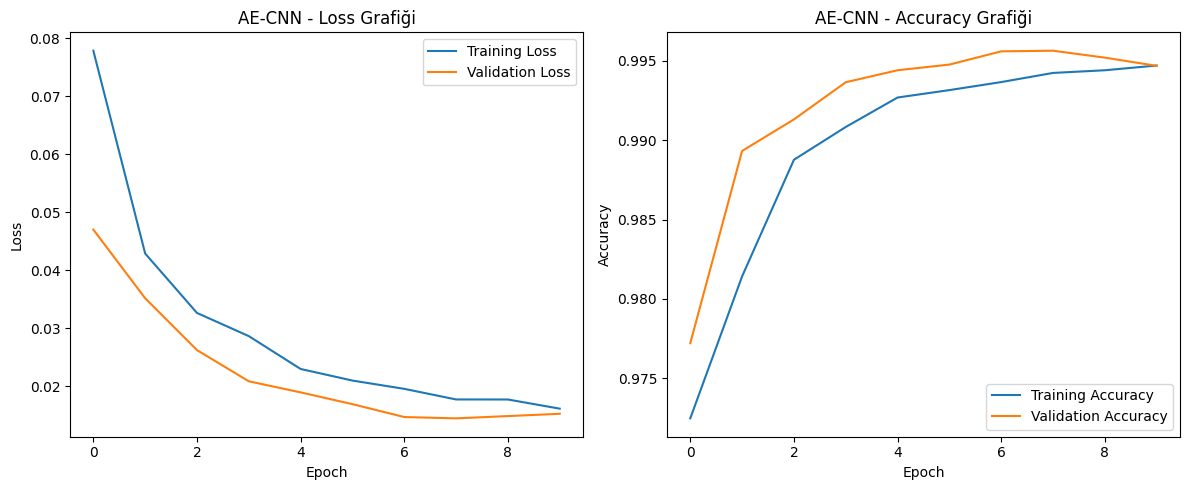

705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
--- AE-CNN MODELİ TEST SONUÇLARI ---
Accuracy: 0.7425
Precision: 0.9147
Recall: 0.6041
F1-Score: 0.7276



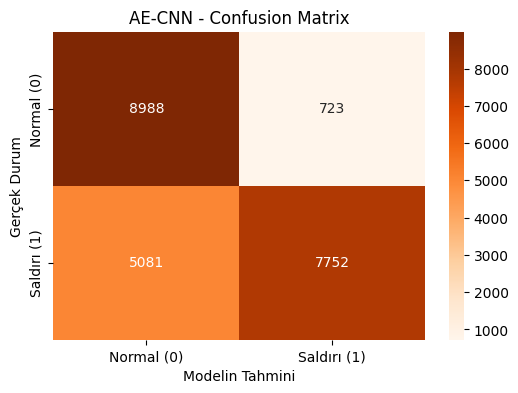

In [ ]:
# AE-CNN Eğitim Grafikleri
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ae_cnn_history.history['loss'], label='Training Loss')
plt.plot(ae_cnn_history.history['val_loss'], label='Validation Loss')
plt.title('AE-CNN - Loss Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ae_cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(ae_cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('AE-CNN - Accuracy Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Test ve Metrikler
y_pred_probs_ae = ae_cnn_model.predict(X_test_cnn)
y_pred_ae = (y_pred_probs_ae > 0.5).astype(int)

print(f"--- AE-CNN MODELİ TEST SONUÇLARI ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ae):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ae):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_ae):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_ae):.4f}\n")

# Confusion Matrix
cm_ae = confusion_matrix(y_test, y_pred_ae)
plt.figure(figsize=(6,4))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal (0)', 'Saldırı (1)'],
            yticklabels=['Normal (0)', 'Saldırı (1)'])
plt.ylabel('Gerçek Durum')
plt.xlabel('Modelin Tahmini')
plt.title('AE-CNN - Confusion Matrix')
plt.show()